# Análisis de impagos bancarios

Los bancos, como intermediarios financieros, prestan dinero a quienes cumplen con los requisitos establecidos. Sin embargo, cuando llega el momento, una parte de los prestatarios incumplen con sus obligaciones y se traspasan en los pagos. Para el mes de julio del presente año, la morosidad en el sistema financiero peruano se ubicó en 4.04%, en las Mypes fue de 8.07% y en las Cajas Rurales fue de 11.25% ( RPP Noticias, 05 de julio de 2021 ). Según Jorge C. ( Diario La República, 09 de febrero de 2020 ), profesor de la Pacífico Business School, comenta que una de las posibles causas es que la gente aglomera gastos […] pequeños e inconscientes a través de las líneas de crédito asignadas a sus trajes (tasa promedio anual de 46%, y en retiro de efectivo es de 120% anual) . La forma en que los bancos evalúan la posibilidad o no de un crédito es a través del Score de calificación crediticia del cliente. Un puntaje mayor significa un perfil crediticio mejor. Otra forma de evaluación es por medio del nivel de ahorro, y este va de cero a doce, significando este último un 'alto nivel de ahorro'. El atraso histórico (en número de días) también juega un rol importante, así como la calificación absoluta del cliente como 'pagador al día' u 'cliente moroso'. De otro lado, la SBS también clasifica el riesgo de cada crédito: 'cero' es normal, y el nivel 'cuatro' es pérdida. Sin embargo ¿Cómo afectaría la morosidad al banco? "Un incremento en la morosidad aumenta el nivel de riesgo, por tanto crecen las provisiones solicitadas por el regulador (dinero inmovilizado, y que no puede ser prestado). Esta es una forma de afectación, como a la rentabilidad de la entidad financiera, por ejemplo" ( Conexión Esan, 13 de diciembre de 2016 ). Viendo desde el punto de vista del banco, la pregunta sería ¿Qué insights podemos encontrar en los datos históricos que nos permiten tomar mejores decisiones antes de efectuar los préstamos? Es así que este trabajo pretende encontrar dichos insights, considerados aún invisibles, y relacionados a la morosidad bancaria peruana a través de la formulación de preguntas sencillas. La revisión, limpieza, transformación y modelación de datos servirán de apoyo en la búsqueda de conclusiones, y la guía en la toma de decisiones.

## N° Variable Descripción
<hr>

<ul style='font-size: 18px; line-height: 2; text-align: justify;'>
    <li><b>Mora: </b>Morosidad del cliente: {0: paga al día, 1: cliente moroso}</li>
    <li><b>Atrasado: </b> Atraso histórico del cliente en días.</li>
    <li><b>Vivienda: </b> Tipo de vivienda del cliente. </li>
    <li><b>Edad: </b> Edad de Cliente. </li>
    <li><b>Dias_lab: </b> Días laborados en su empleado actual.</li>
    <li><b>Exp_sf: </b> Meses con experiencias en el sistema financiero, en decir el número de meses que tiene el cliente desde que adquirió algún producto financieros. </li>
    <li><b>Nivel_ahorro: </b> índece del nivel de ahorro del cliente: {0: no tiene ahorros, 12: alto nivel de ahorros} </li>
    <li><b>Ingreso: </b> ingresos del cliente.</li>
    <li><b>Línea_sf: </b> Línea de crédito en el sistema financiero que el cliente tiene disponible.</li>
    <li><b>Deuda_sf: </b> Deuda del cliente en el sistema financiero.</li>
    <li><b>Score: </b> Calificación crediticia del cliente. Mientras mayor es el puntaje, mejor perfil crediticio tiene el cliente. </li>
    <li><b>Zona: </b> Departamento de residencia del cliente.</li>
    <li><b>Clasif_sbs: </b> Clasificación SBS. Mientras mayor es el número, peor clasificación tiene el cliente: {0: normal, 1: con problemas pontenciales, 2: deficinte, 3: duduso, 4: pérdida} </li>
    <li><b>Nivel_educ: </b> Nivel educativo máximo alcanzado por el cliente,</li>
    
</ul>


# Nueva sección

In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode, iplot

In [250]:
df = pd.read_csv('data.csv')
df.head()

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ
0,0,235,FAMILIAR,30,3748,93.0,5,3500.0,NaN,0.00,214,Lima,4,UNIVERSITARIA
1,0,18,FAMILIAR,32,4598,9.0,12,900.0,1824.67,1933.75,175,La Libertad,1,TECNICA
2,0,0,FAMILIAR,26,5148,8.0,2,2400.0,2797.38,188.29,187,Lima,0,UNIVERSITARIA
3,0,0,FAMILIAR,36,5179,20.0,12,2700.0,NaN,0.00,187,Ancash,0,TECNICA
4,0,0,FAMILIAR,46,3960,NaN,1,3100.0,2000.00,11010.65,189,Lima,0,TECNICA


In [251]:
df.shape

(8399, 14)

In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   object 
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   object 
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 918.8+ KB


In [253]:
df.isnull().sum()

,0
mora,0
atraso,0
vivienda,0
edad,0
dias_lab,0
exp_sf,1830
nivel_ahorro,0
ingreso,0
linea_sf,1127
deuda_sf,461


In [254]:
print('Edad\n',df.edad.sort_values().unique())#valores unicos de edad
print('Score\n',df.score.sort_values().unique())#valores unicos de score

Edad
 [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43
 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67
 68 69 70 71 74 76 79 85]
Score
 [134 136 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 242 243 245 246 247 249 250 252 254 257 261
 264 266]


In [255]:
df.fillna(0, inplace=True)  #Agregar en datos Nulos.

df.exp_sf = df.exp_sf.astype(int) #Convertir en float en int


In [256]:


#Rangos de edad para un mejor orde.
bins =[19,30,40,50,60,100]
labels = ['20-30','30-40','40-50','50-60','60+']
df['rango_edad'] = pd.cut(df['edad'],bins,labels=labels)

#rango de score para un orden mejor
bins1 = [120,180,220,280]
labels1 = ['Bajo', 'Medio','Alto']
df['score_rango'] = pd.cut(df['score'],bins1,labels=labels1)

df.sample(10, random_state=42)

,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ,rango_edad,score_rango
33,0,0,FAMILIAR,29,4721,8,12,2600.0,1075.95,747.40,200,Lima,0,UNIVERSITARIA,20-30,Medio
5281,0,3,FAMILIAR,55,5574,55,12,2500.0,4818.07,7750.85,211,Lima,0,TECNICA,50-60,Medio
4912,1,0,PROPIA,24,7186,0,12,4000.0,0.00,10440.85,190,Moquegua,0,TECNICA,20-30,Medio
3298,1,33,FAMILIAR,40,3773,16,12,873.1,500.00,2461.67,180,Callao,2,TECNICA,30-40,Bajo
4756,1,2,FAMILIAR,50,6762,0,12,2100.0,0.00,0.00,205,Arequipa,0,UNIVERSITARIA,40-50,Medio
5433,1,0,FAMILIAR,26,5360,33,12,3300.0,14498.53,3714.33,213,Lima,0,UNIVERSITARIA,20-30,Medio
1429,0,0,FAMILIAR,30,5939,43,12,5000.0,16281.32,1019.65,200,Lima,0,UNIVERSITARIA,20-30,Medio
1297,0,0,FAMILIAR,42,8404,102,12,4950.0,26361.40,832.68,205,Lima,0,UNIVERSITARIA,40-50,Medio
4921,1,0,PROPIA,47,11357,0,12,4306.0,0.00,0.00,219,Lima,1,UNIVERSITARIA,40-50,Medio
533,0,0,PROPIA,33,4174,41,12,7500.0,28521.65,0.00,224,Callao,0,UNIVERSITARIA,30-40,Alto


# ¿Cuál es la relación entre el nivel de ahorro y la deuda?



### 1. Análisis del gráfico principal (Nivel de Ahorro vs. Deuda Promedio):

* la deuda promedio varia en forma cociderable al nivel de ahorro.
* las deudas mas alta al rededor de 14 mil en promedio estan en los niveles 3 y 4, esto podria deberce un conpromiso financiero significativo de a pesar de tener cierto nive de ahorro.
* Los niveles de ahorro entre 5 y 12 presentan una menor deuda promedio, manteniéndose en una tendencia más baja y estable.
* Los niveles de ahorro entre 0 y 2 muestran una deuda promedio menor (alrededor de 4,000 a 8,000), lo cual puede deberse a una menor capacidad de acceso al crédito o a menores compromisos financieros.

### 2. Análisis del secundario (inserto) (Nivel de Ahorro vs. Ingreso Promedio):

* En general se observa una variación de el ingreso promedio conforme aumenta el nivel de ahorro.
* los niveles de ahorro 3 y 4 tienen deudas altas, los ingresos promedio no parecen ser los más altos, lo que podría sugerir que estas personas tienen más dificultad para manejar su deuda en relación con su ingreso.
* En los niveles mas altos de entre 9 y 12 un ingreso promedio mas bajo, lo cual indica que esta persona priorizan el ahorro frete al consumo, lo cual le ayuda mantener la deuda mas controlada.

## Conclucsiones y recomendacione:


1.   punto a mejorar: Los niveles de ahorro 3 y 4 tienen sus deudas altas en consideración de sus ingresos, seria adecuado diseñar estrategia de educación financiera.
2.   aspectos positivos:Las personas con un nivel de ahorro entre 5 y 12 tienen un control más balanceado de su deuda, con niveles de deuda más bajos. Esto sugiere una actitud financiera más conservadora y orientada hacia la estabilidad.
3.



Text(0.5, 1.0, 'Nivel de ahorro vs Ingreso promedio')

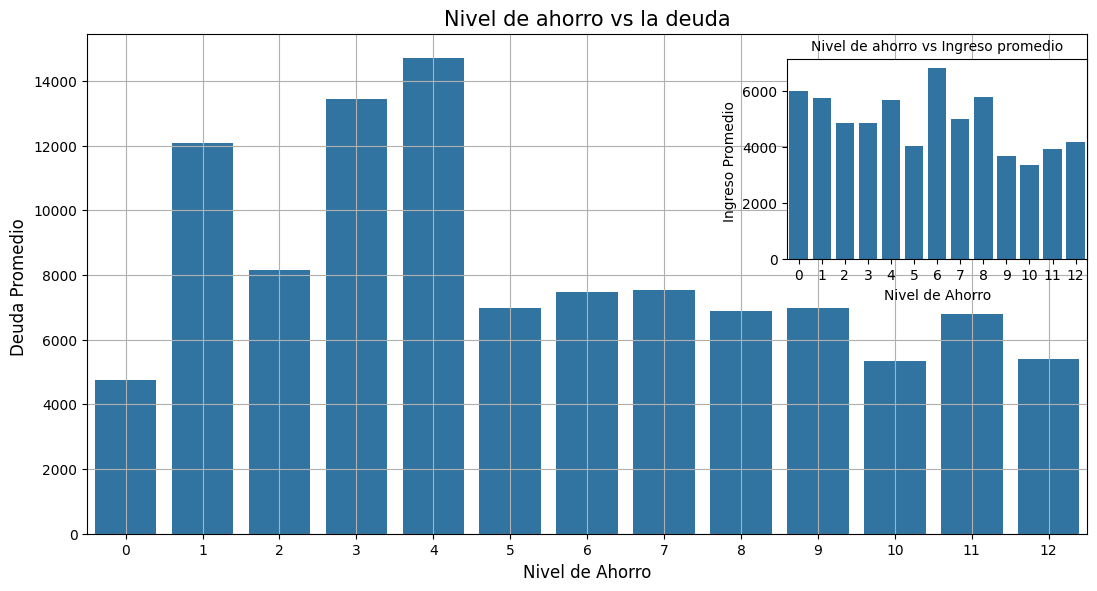

In [257]:
deuda_por_ahorro = df.groupby('nivel_ahorro')['deuda_sf'].mean().reset_index() #agrupamiento de promedio de deuda_sf en funcion de nivel_ahorro
ingreso_por_ahorro = df.groupby('nivel_ahorro')['ingreso'].mean().reset_index()#agrupamiento de promedio de ingreso en funcion de nivel_ahorro

# Graficar
fig = plt.figure(figsize=(10, 5))#tamaño de la grafica
eje = fig.add_subplot([0,0,1,1])#poción y tamaño en funcion de fig
sns.barplot(x='nivel_ahorro', y='deuda_sf', data=deuda_por_ahorro)# grafica de barras en libreria de seaborn
eje.set_xlabel('Nivel de Ahorro', fontsize = 12)#nombre del valor de x
eje.set_ylabel('Deuda Promedio ', fontsize = 12)#nombre del valor de y
eje.set_title('Nivel de ahorro vs la deuda', fontsize = 15)# titulo de la grafica
eje.grid(True)#cuadricula


eje2 = fig.add_subplot([0.7,0.55,0.3,0.4]) #poción y tamaño en funcion de fig

sns.barplot(x='nivel_ahorro', y='ingreso', data=ingreso_por_ahorro)# grafica de barras en libreria de seaborn
eje2.set_xlabel('Nivel de Ahorro',fontsize=10)#nombre del valor de x pequeña
eje2.set_ylabel('Ingreso Promedio ',fontsize=10)#nombre del valor de y pequeña
eje2.set_title('Nivel de ahorro vs Ingreso promedio',fontsize=10)#titulo del grafica pequeña

# ¿Cuál es la relación entre el nivel de ahorro y rango de edad?



### 1. Análisis del gráfico principal (Rango de Edad vs. Ingreso Promedio):


*   Los rangos de 20-30 y 30-40 tienen un ingreso promedio más bajo, que ronda entre los 2,000 a 4,000.
*   A partir de los 40 años, el ingreso promedio se estabiliza en niveles más altos, con un incremento significativo en el rango de 60+ que llega a un promedio cercano a 10,000.
* Esto sugiere que la estabilidad y crecimiento en los ingresos se alcanza con la experiencia y la permanencia en el mercado laboral.

### 2. Análisis del gráfico inserto (Rango de Edad vs. Número de Préstamos):

* Los rangos de edad de 20-30 y 30-40 son los que tienen un mayor número de préstamos, con más de 2,500 personas en cada grupo.
* A medida que avanza la edad, el número de personas con préstamos disminuye considerablemente.
*Esto puede ser un reflejo de que las personas más jóvenes tienen una mayor necesidad de financiamiento para establecerse económicamente (por ejemplo, para comprar una vivienda, vehículo, o iniciar negocios).

### 3. Conclusiones y recomendaciones:
* El gráfico revela una tendencia positiva de crecimiento de ingresos con la edad, pero también indica la necesidad de apoyar a los más jóvenes en la gestión de sus préstamos, para que puedan establecer una base financiera más sólida a lo largo de su vida.

<ipython-input-258-e830d1e03eed>:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<ipython-input-258-e830d1e03eed>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



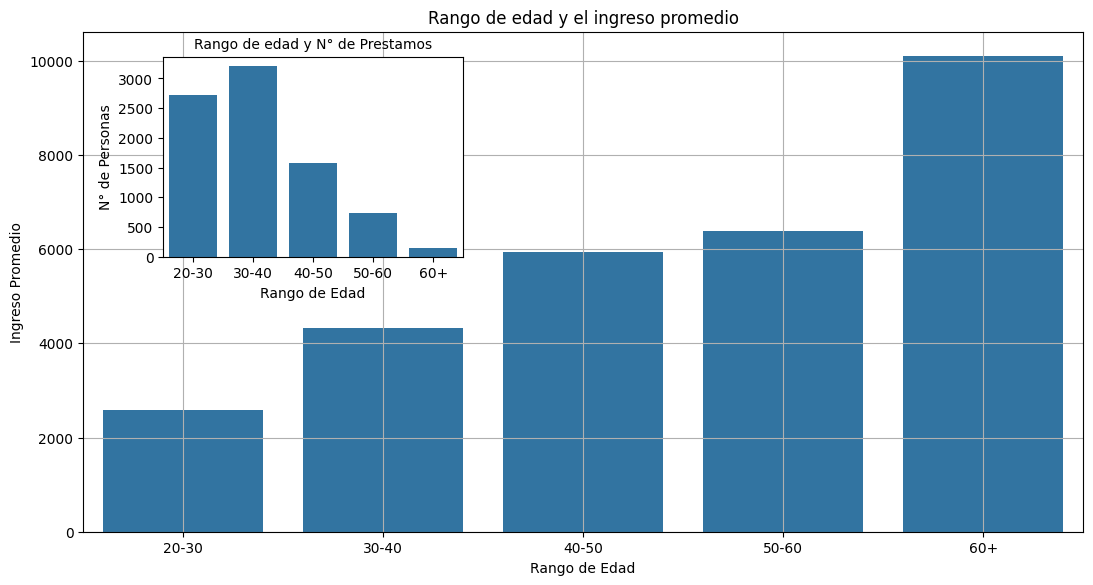

In [258]:
rango_edad_ingreso = df.groupby('rango_edad')['ingreso'].mean().reset_index()
rango_edad_ingreso_cantidad = df.groupby('rango_edad')['ingreso'].size().reset_index()
fig = plt.figure(figsize=(10, 5))
eje = fig.add_subplot([0,0,1,1])
sns.barplot(x='rango_edad', y='ingreso', data=rango_edad_ingreso)
eje.set_xlabel('Rango de Edad')
eje.set_ylabel('Ingreso Promedio')
eje.set_title('Rango de edad y el ingreso promedio', color = 'Black')
eje.grid(True)
fig.savefig('rango_edad_ingreso.png',bbox_inches = 'tight')

eje2 = fig.add_subplot([0.08,0.55,0.3,0.4])

sns.barplot(x='rango_edad', y='ingreso', data=rango_edad_ingreso_cantidad)
eje2.set_xlabel('Rango de Edad', fontsize=10)
eje2.set_ylabel('N° de Personas', fontsize=10)
eje2.set_title('Rango de edad y N° de Prestamos', fontsize=10)

plt.show()

# ¿Cómo influye el historial de atrasos en la probabilidad de incumplimiento de pagos?



*   Datos: Historial de atrasos (días de atraso) y estado del cliente (pagador al día o moroso).
*   Código: Se Realizan un análisis de regresión logística para modelar la probabilidad de incumplimiento de pagos en función de los días de atraso. utilizando scikit-learn para construir el modelo de regresión.



In [259]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix



*   Contando una Precisión del modelo: 0.69, implica que de todas las predicciones realizadas por el modelo sobre los datos de prueba, el 69% fueron correctas, y el 31% fueron incorrectas.




In [260]:
# Datos
X = df[['atraso']]  # Predictor: días de atraso
y = df['mora']  # Objetivo: 0 (al día) o 1 (moroso)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Predicción y evaluación
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Precisión del modelo: {accuracy:.2f}')



Precisión del modelo: 0.69


# ¿Qué factores afectan más la calificación crediticia?

* Gestión del Riesgo: La fuerte influencia de la deuda en el modelo implica que para reducir el riesgo, es fundamental prestar atención a la gestión de las deudas de los individuos. Estrategias como refinanciación o políticas de límite de deuda podrían ser eficaces.
* Promoción del Ahorro: Dado que el nivel de ahorro influye en la clasificación, se podría deducir que fomentar una mayor tasa de ahorro entre los individuos puede ser una medida complementaria para reducir el riesgo.
Posibles Mejoras del Modelo

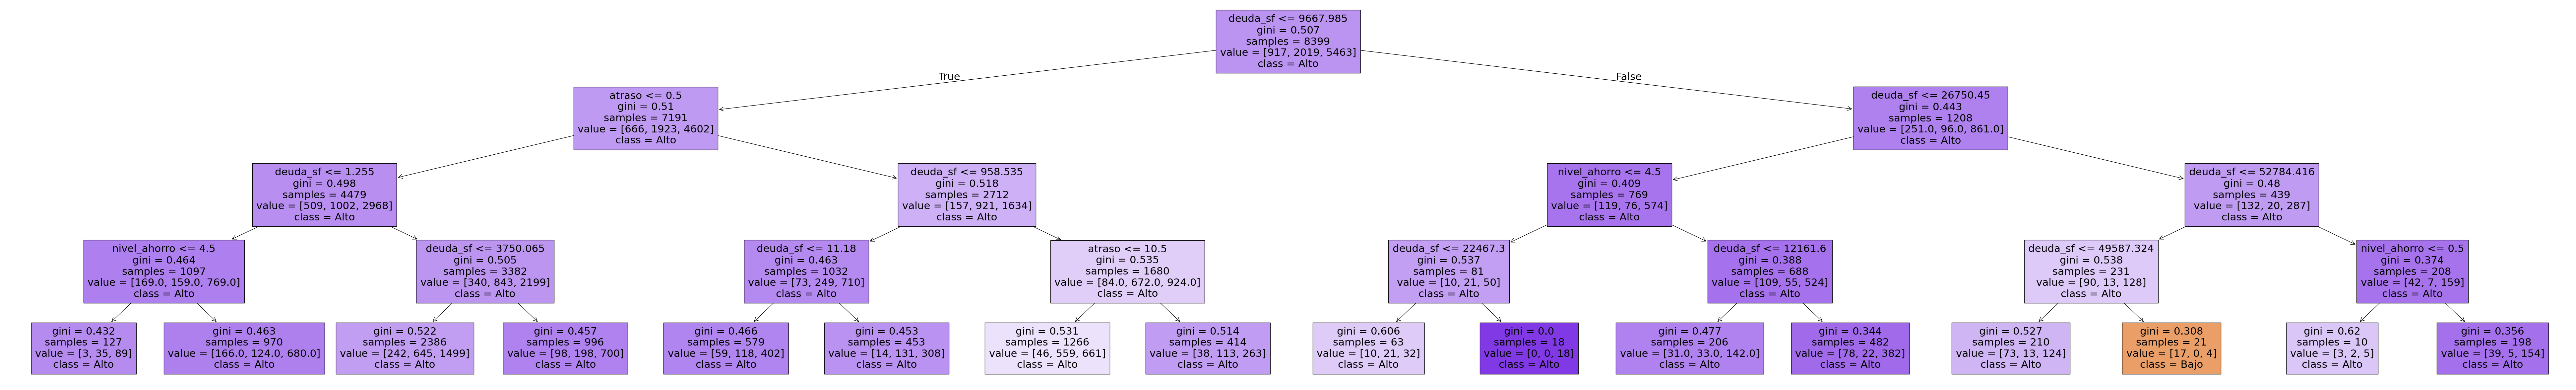

In [261]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Datos
X = df[['nivel_ahorro', 'atraso', 'deuda_sf']]  # Predictores
y = df['score_rango']  # Objetivo

# Entrenar el modelo
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X, y)


# Visualizar el árbol de decisión
plt.figure(figsize=(100, 15))
plot_tree(arbol, feature_names=X.columns, class_names=['Bajo', 'Medio', 'Alto'], filled=True)
plt.show()


La imagen muestra un árbol de decisión que clasifica a los individuos en dos categorías: UNIVERSITARIA y TECNICA, utilizando variables como deuda_sf, nivel_ahorro, y atraso. La variable deuda_sf es un determinante principal en las primeras divisiones del árbol, lo que indica que la deuda influye significativamente en la clasificación de los individuos. El nivel_ahorro también aparece como un factor relevante, especialmente para diferenciar entre aquellos con mayores o menores capacidades de pago

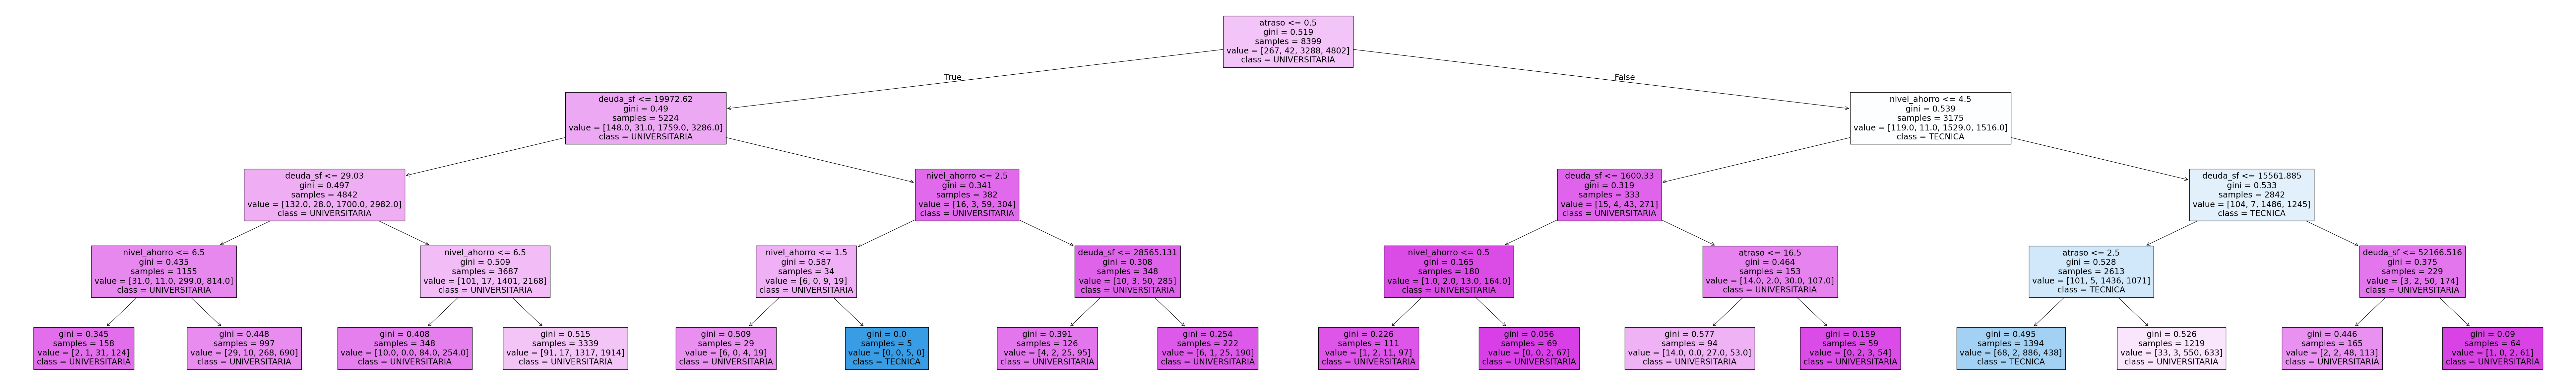

In [262]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Datos
X = df[['nivel_ahorro', 'atraso', 'deuda_sf']]  # Predictores
y = df['nivel_educ']  # Objetivo

# Entrenar el modelo
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X, y)


# Visualizar el árbol de decisión
plt.figure(figsize=(100, 15))
plot_tree(arbol, feature_names=X.columns, class_names=['SECUNDARIA', 'SIN EDUCACION','TECNICA' , 'UNIVERSITARIA'], filled=True)
plt.show()

# ¿Cuál es el perfil de un cliente con alto riesgo crediticio?


Este conjunto de datos, con 1090 registros, muestra un nivel_ahorro promedio de 5.18, con una alta variabilidad (std = 4.51). La mayoría de los registros tienen un ahorro de 0 a 10, y el valor máximo es 11. El atraso promedio es 7.03, pero hay una gran dispersión debido a algunos casos extremos (hasta 238 días). La mayoría de los casos no tienen atraso, con un percentil del 75% en 6 días. La deuda_sf tiene un promedio de 5493.17, con valores muy dispersos y algunos valores extremos que alcanzan los 57094.38, aunque el 50% de las deudas es inferior a 1486.84.

In [263]:
# Filtrar clientes con bajo score crediticio
clientes_riesgo = df[(df['nivel_ahorro']< 12) & (df['score'] < 200) ] # Asumiendo que score < 200 es alto riesgo y nivel ahorro < 12

# Describir el perfil de estos clientes
perfil = clientes_riesgo[['nivel_ahorro', 'atraso', 'deuda_sf']].describe()
perfil


,nivel_ahorro,atraso,deuda_sf
count,1090.000000,1090.000000,1090.000000
mean,5.176147,7.031193,5493.169495
std,4.505907,21.510946,11105.682440
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,56.707500
50%,5.000000,0.000000,1486.840000
75%,10.000000,6.000000,4733.007500
max,11.000000,238.000000,57094.380000
